In [24]:
import os

In [48]:
print(os.listdir('./flowers'))

['.DS_Store', 'daisy', 'rose', 'tulip', 'dandelion', 'sunflower']


In [49]:
# Ignore  the warnings
import warnings
warnings.filterwarnings('always')
warnings.filterwarnings('ignore')

# data visualisation and manipulation
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import style
import seaborn as sns

import tensorflow as tf
import random as rn
 
#configure
# sets matplotlib to inline and displays graphs below the corressponding cell.
%matplotlib inline  
style.use('fivethirtyeight')
sns.set(style='whitegrid',color_codes=True)

#model selection
from sklearn.model_selection import train_test_split
from sklearn.model_selection import KFold
from sklearn.metrics import accuracy_score,precision_score,recall_score,confusion_matrix,roc_curve,roc_auc_score, classification_report
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import LabelEncoder

#preprocess.
from tensorflow.keras.preprocessing.image import ImageDataGenerator

#dl libraraies
from keras import backend as K
from keras.models import Sequential
from keras.layers import Dense
from keras.optimizers import Adam,SGD,Adagrad,Adadelta,RMSprop
from keras.utils import to_categorical

# specifically for cnn
from keras.layers import Dropout, Flatten,Activation
from keras.layers import Conv2D, MaxPooling2D, BatchNormalization
 


# specifically for manipulating zipped images and getting numpy arrays of pixel values of images.
import cv2                  
import numpy as np  
from tqdm import tqdm
import os                   
from random import shuffle  
from zipfile import ZipFile
from PIL import Image

In [50]:
X=[]
Z=[]
IMG_SIZE=150
FLOWER_DAISY_DIR='./flowers/daisy'
FLOWER_SUNFLOWER_DIR='./flowers/sunflower'
FLOWER_TULIP_DIR='./flowers/tulip'
FLOWER_DANDI_DIR='./flowers/dandelion'
FLOWER_ROSE_DIR='./flowers/rose'

In [51]:
def assign_label(img,flower_type):
    return flower_type

In [52]:
def make_train_data(flower_type, DIR):
    for img_name in tqdm(os.listdir(DIR)):
        path = os.path.join(DIR, img_name)
        # Skip folders and non-files
        if not os.path.isfile(path):
            continue
        # Read image
        img = cv2.imread(path, cv2.IMREAD_COLOR)
        # Skip unreadable / invalid images
        if img is None:
            print("Skipping unreadable image:", path)
            continue

        # Assign label
        label = assign_label(img_name, flower_type)
        # Resize
        img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
        X.append(np.array(img))
        Z.append(str(label))

In [53]:
# Daisy
make_train_data('Daisy',FLOWER_DAISY_DIR)
print(len(X))

# # Sunflower
# make_train_data('Sunflower',FLOWER_SUNFLOWER_DIR)
# print(len(X))

# # Tulip
# make_train_data('Tulip',FLOWER_TULIP_DIR)
# print(len(X))

# # Dandelion
# make_train_data('Dandelion',FLOWER_DANDI_DIR)
# print(len(X))

# Rose
make_train_data('Rose',FLOWER_ROSE_DIR)
print(len(X))

 27%|█████████████████████▌                                                         | 221/811 [00:00<00:01, 542.01it/s]

Skipping unreadable image: ./flowers/daisy/.DS_Store


100%|███████████████████████████████████████████████████████████████████████████████| 811/811 [00:01<00:00, 595.52it/s]


810


 28%|██████████████████████                                                         | 237/850 [00:00<00:01, 593.85it/s]

Skipping unreadable image: ./flowers/rose/.DS_Store


100%|███████████████████████████████████████████████████████████████████████████████| 850/850 [00:01<00:00, 594.87it/s]

1659


In [54]:
# fig,ax=plt.subplots(5,2)
# fig.set_size_inches(15,15)
# for i in range(5):
#     for j in range (2):
#         l=rn.randint(0,len(Z))
#         ax[i,j].imshow(X[l])
#         ax[i,j].set_title('Flower: '+Z[l])
#         ax[i, j].axis('off')

        
# plt.tight_layout()

In [55]:
le=LabelEncoder()
Y=le.fit_transform(Z)
Y=to_categorical(Y,5)
X=np.array(X)
X=X/255

In [56]:
x_train,x_test,y_train,y_test=train_test_split(X,Y,test_size=0.25,random_state=42)

In [57]:
np.random.seed(42)
rn.seed(42)
tf.random.set_seed(42)
input_shape = (150,150,3)

In [74]:
model = Sequential()
model.add(Conv2D(filters = 32, kernel_size = (5,5),padding = 'Same',activation ='relu', input_shape = input_shape))
model.add(MaxPooling2D(pool_size=(2,2)))


model.add(Conv2D(filters = 64, kernel_size = (3,3),padding = 'Same',activation ='relu'))
model.add(MaxPooling2D(pool_size=(2,2), strides=(2,2)))
 

model.add(Conv2D(filters =96, kernel_size = (3,3),padding = 'Same',activation ='relu'))
model.add(MaxPooling2D(pool_size=(2,2), strides=(2,2)))

model.add(Conv2D(filters = 96, kernel_size = (3,3),padding = 'Same',activation ='relu'))
model.add(MaxPooling2D(pool_size=(2,2), strides=(2,2)))

model.add(Flatten())
model.add(Dense(512))
model.add(Dropout(0.3))
model.add(Activation('relu'))
model.add(Dropout(0.3))
model.add(Dense(5, activation = "softmax"))

In [75]:
batch_size=128
epochs=50

from keras.callbacks import ReduceLROnPlateau
red_lr= ReduceLROnPlateau(monitor='val_acc',patience=3,verbose=1,factor=0.1)

In [76]:
datagen = ImageDataGenerator(
        featurewise_center=False,  # set input mean to 0 over the dataset
        samplewise_center=False,  # set each sample mean to 0
        featurewise_std_normalization=False,  # divide inputs by std of the dataset
        samplewise_std_normalization=False,  # divide each input by its std
        zca_whitening=False,  # apply ZCA whitening
        rotation_range=10,  # randomly rotate images in the range (degrees, 0 to 180)
        zoom_range = 0.1, # Randomly zoom image 
        width_shift_range=0.2,  # randomly shift images horizontally (fraction of total width)
        height_shift_range=0.2,  # randomly shift images vertically (fraction of total height)
        horizontal_flip=True,  # randomly flip images
        vertical_flip=False)  # randomly flip images


datagen.fit(x_train)

In [77]:
# model.summary()

# model.compile(optimizer=Adam(learning_rate=0.001),loss='categorical_crossentropy',metrics=['accuracy'])

model.compile(loss="categorical_crossentropy", optimizer="adam", metrics=["accuracy"])


In [78]:
model.summary()


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_12 (Conv2D)              │ (None, 150, 150, 32)   │         2,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_12 (MaxPooling2D) │ (None, 75, 75, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 75, 75, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_13 (MaxPooling2D) │ (None, 37, 37, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 37, 37, 96)     │        55,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_14 (MaxPooling2D) │ (None, 18, 18, 96)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_15 (Conv2D)              │ (None, 18, 18, 96)     │        83,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_15 (MaxPooling2D) │ (None, 9, 9, 96)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 7776)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 512)            │     3,981,824 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 5)              │         2,565 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,143,749 (15.81 MB)

 Trainable params: 4,143,749 (15.81 MB)

 Non-trainable params: 0 (0.00 B)

In [80]:
History = model.fit(datagen.flow(x_train,y_train, batch_size=batch_size),
                              epochs = epochs, validation_data = (x_test,y_test),
                              verbose = 1, steps_per_epoch=x_train.shape[0] // batch_size)
# model.fit(x_train,y_train,epochs=epochs,batch_size=batch_size,validation_data = (x_test,y_test))

Epoch 1/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 8s 769ms/step - accuracy: 0.4875 - loss: 0.8634 - val_accuracy: 0.5783 - val_loss: 0.6736
Epoch 2/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 79ms/step - accuracy: 0.4844 - loss: 0.7039 - val_accuracy: 0.6578 - val_loss: 0.6549
Epoch 3/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 6s 703ms/step - accuracy: 0.5869 - loss: 0.6702 - val_accuracy: 0.7277 - val_loss: 0.5601
Epoch 4/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 80ms/step - accuracy: 0.5859 - loss: 0.6567 - val_accuracy: 0.7542 - val_loss: 0.5629
Epoch 5/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 7s 707ms/step - accuracy: 0.6783 - loss: 0.6070 - val_accuracy: 0.7590 - val_loss: 0.5158
Epoch 6/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 79ms/step - accuracy: 0.7578 - loss: 0.4788 - val_accuracy: 0.7494 - val_loss: 0.5269
Epoch 7/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 6s 705ms/step - accuracy: 0.7240 - loss: 0.5756 - val_accuracy: 0.7711 - val_loss: 0.5203
Epoch 8/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 79ms/step - accuracy: 0.7422 - loss: 0.5906 - val_accuracy: 0.7831 - val_loss: 0.5

In [81]:
def graph_view(parameter1, parameter2, parameter3, parameter4, parameter5, graph_set):
    print("graph_set", graph_set)
    plt.plot(History.history[parameter1])
    plt.plot(History.history[parameter2])
    plt.title(parameter3)
    plt.ylabel(parameter4)
    plt.xlabel(parameter5)
    plt.legend(graph_set)
    plt.show()
    return

graph_set ['train', 'test']


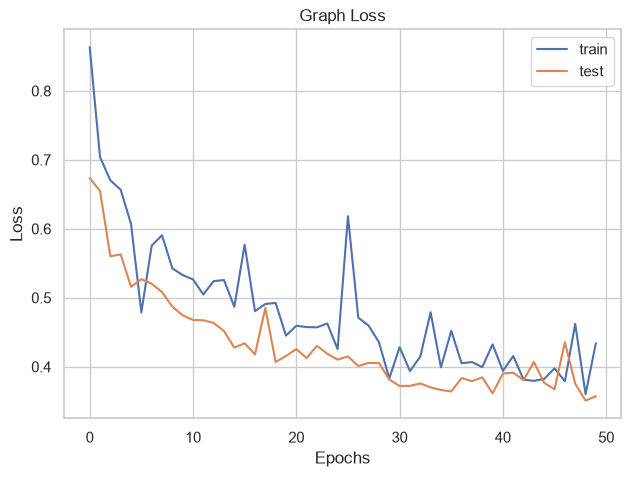

In [82]:
graph_view("loss", "val_loss", "Graph Loss", "Loss", "Epochs", ['train', 'test'])

graph_set ['train', 'test']


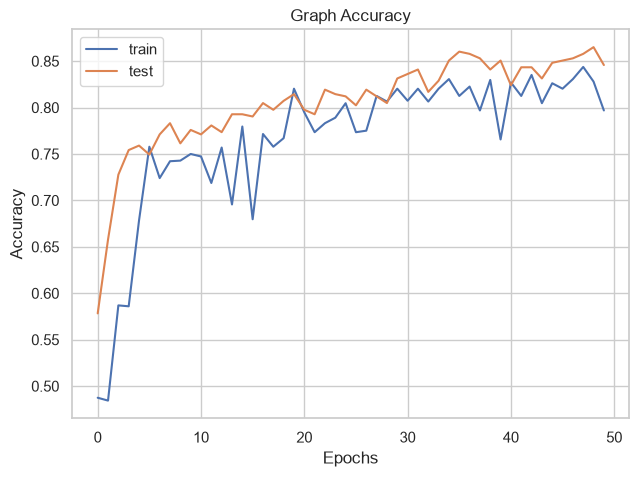

In [83]:
graph_view("accuracy", "val_accuracy", "Graph Accuracy", "Accuracy", "Epochs", ['train', 'test'])

In [84]:
# getting predictions on val set.
pred=model.predict(x_test)
pred_digits=np.argmax(pred,axis=1)

13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 50ms/step


In [85]:
actual_classes = np.argmax(y_test, axis=1)

correct_indices = np.flatnonzero(
    actual_classes == pred_digits
)[:8].tolist()

incorrect_indices = np.flatnonzero(
    actual_classes != pred_digits
)[:8].tolist()


In [90]:
def predict_image (class_function, pred_digit,  plot,plot1, size, size1, X, Y):
    warnings.filterwarnings('always')
    warnings.filterwarnings('ignore')
    count = 0
    fig, ax = plt.subplots(plot, plot1)
    fig.set_size_inches(size, size1)

    for i in range(4):
        for j in range(2):

            idx = class_function[count]

            ax[i, j].imshow(X[idx])

            predicted_class = pred_digit[idx]
            actual_class = np.argmax(Y[idx])

            predicted_flower = le.inverse_transform([predicted_class])[0]
            actual_flower = le.inverse_transform([actual_class])[0]

            ax[i, j].set_title(
                "Predicted Flower : " + predicted_flower +
                "\nActual Flower : " + actual_flower
            )

            ax[i, j].axis('off')

            count += 1

    plt.tight_layout()
    plt.show()
    return

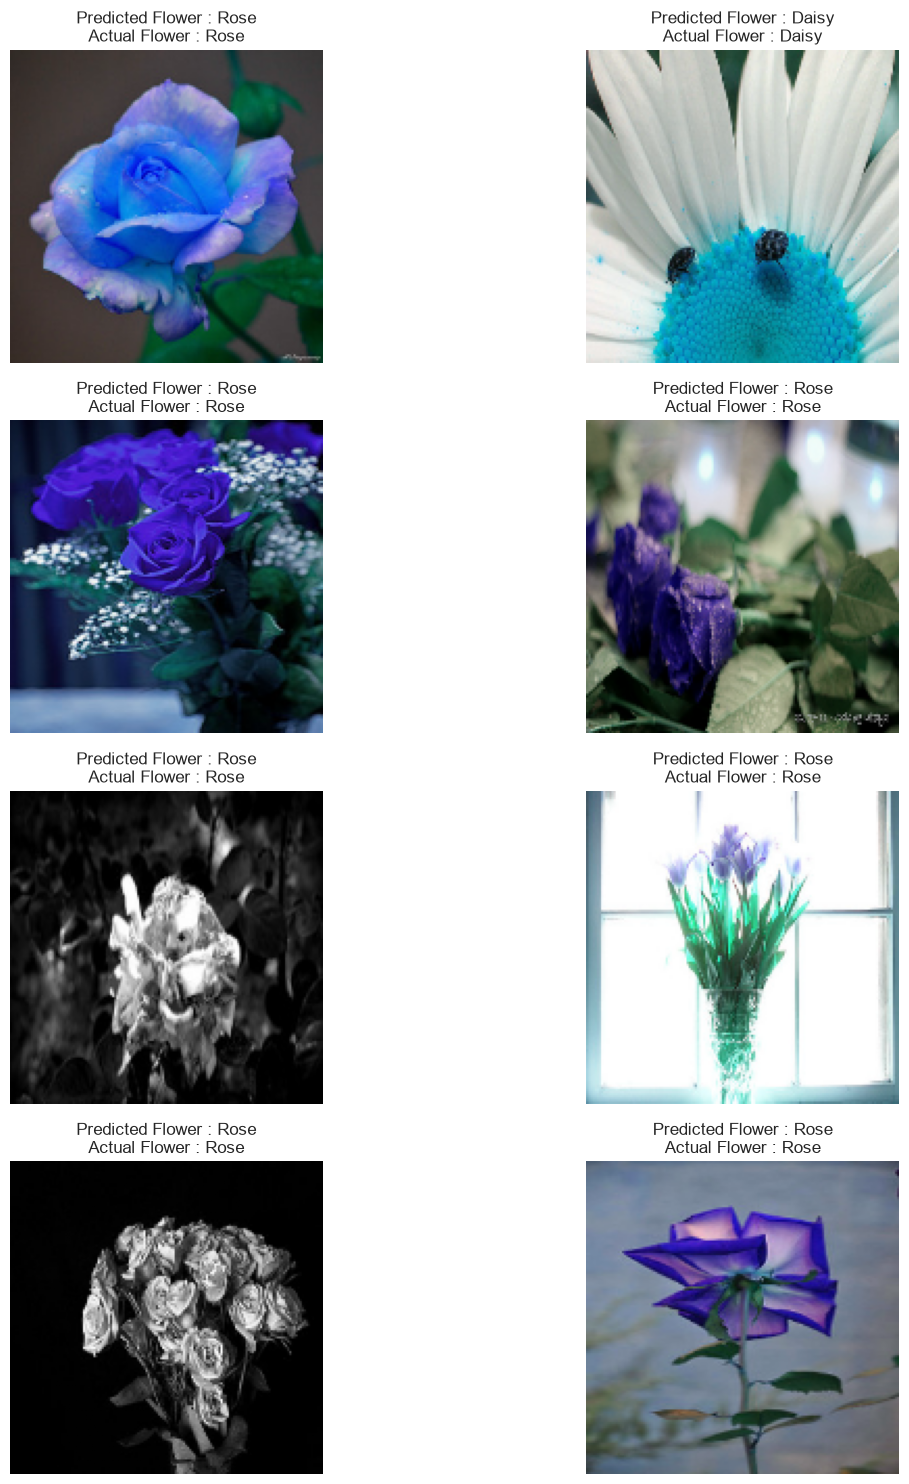

In [91]:
predict_image(correct_indices, pred_digits, 4, 2, 15, 15, x_test, y_test)


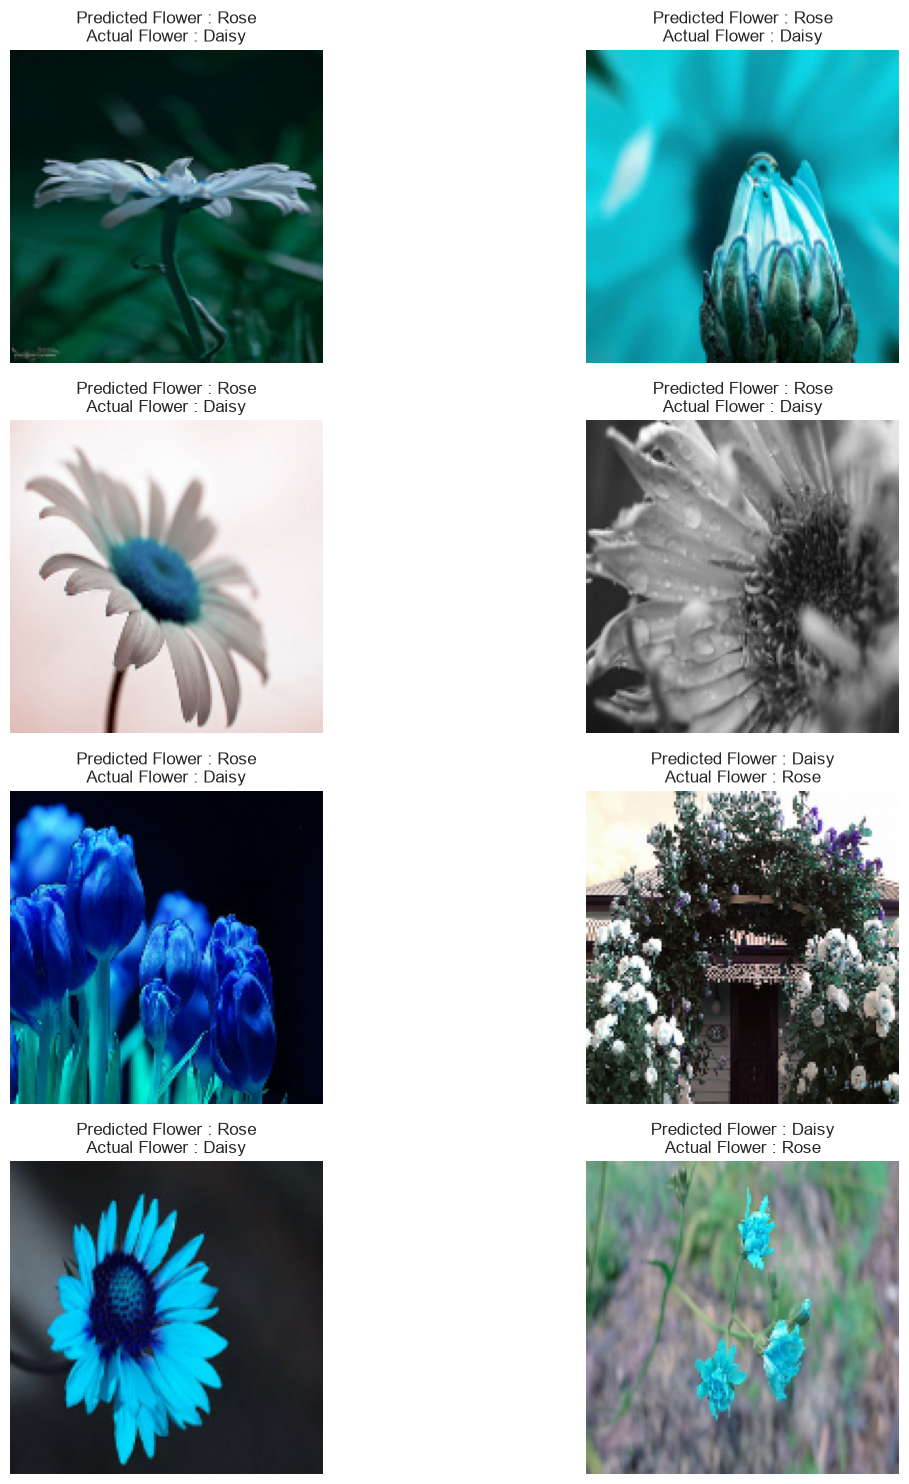

In [92]:
predict_image(incorrect_indices, pred_digits, 4, 2, 15, 15, x_test, y_test)

In [93]:
# Predicted class indices
pred_probabilities = model.predict(x_test)
pred_digits = np.argmax(pred_probabilities, axis=1)

# Actual class indices
y_test_digit_level = np.argmax(y_test, axis=1)

print(
    classification_report(
        y_test_digit_level,
        pred_digits,
        labels=np.arange(len(le.classes_)),
        target_names=le.classes_,
        zero_division=0
    )
)

13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 48ms/step
              precision    recall  f1-score   support

       Daisy       0.92      0.76      0.83       210
        Rose       0.79      0.93      0.86       205

    accuracy                           0.85       415
   macro avg       0.86      0.85      0.84       415
weighted avg       0.86      0.85      0.84       415

